In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats 
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("E:/Project/Submissions/Datasets/df_reduced_pca.csv")

In [3]:
df

,day,month,partly-cloudy-night,cloudy,temperatureHigh,energy_sum,visibility,windSpeed,rain,energy_min,moonPhase,date,clear-day,pressure,uvIndex
0,2011-11-24,11,0,0,15.57,12.135,12.68,2.45,1,0.092,0.21,24,0,1009.46,1.0
1,2011-11-24,11,0,0,15.57,2.304,12.68,2.45,1,0.047,0.21,24,0,1009.46,1.0
2,2011-11-24,11,0,0,15.57,8.394,12.68,2.45,1,0.036,0.21,24,0,1009.46,1.0
3,2011-11-24,11,0,0,15.57,4.620,12.68,2.45,1,0.023,0.21,24,0,1009.46,1.0
4,2011-11-24,11,0,0,15.57,14.258,12.68,2.45,1,0.127,0.21,24,0,1009.46,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2949619,2014-02-27,2,0,0,9.21,0.467,9.08,1.64,1,0.000,0.01,27,0,1002.50,2.0
2949620,2014-02-27,2,0,0,9.21,7.671,9.08,1.64,1,0.025,0.01,27,0,1002.50,2.0
2949621,2014-02-27,2,0,0,9.21,10.138,9.08,1.64,1,0.023,0.01,27,0,1002.50,2.0
2949622,2014-02-27,2,0,0,9.21,1.824,9.08,1.64,1,0.009,0.01,27,0,1002.50,2.0


In [4]:
df.columns

Index(['day', 'month', 'partly-cloudy-night', 'cloudy', 'temperatureHigh',
       'energy_sum', 'visibility', 'windSpeed', 'rain', 'energy_min',
       'moonPhase', 'date', 'clear-day', 'pressure', 'uvIndex'],
      dtype='object')

In [5]:
# Convert 'date' to datetime format
df['day'] = pd.to_datetime(df['day'])

# Set 'date' as the index
df.set_index('day', inplace=True)

In [6]:
# Check for missing values
print(df['energy_sum'].isnull().sum())

0


In [7]:
# Selecting target variable (energy_sum as an example)
target_col = 'energy_sum'
df_re = df[target_col]

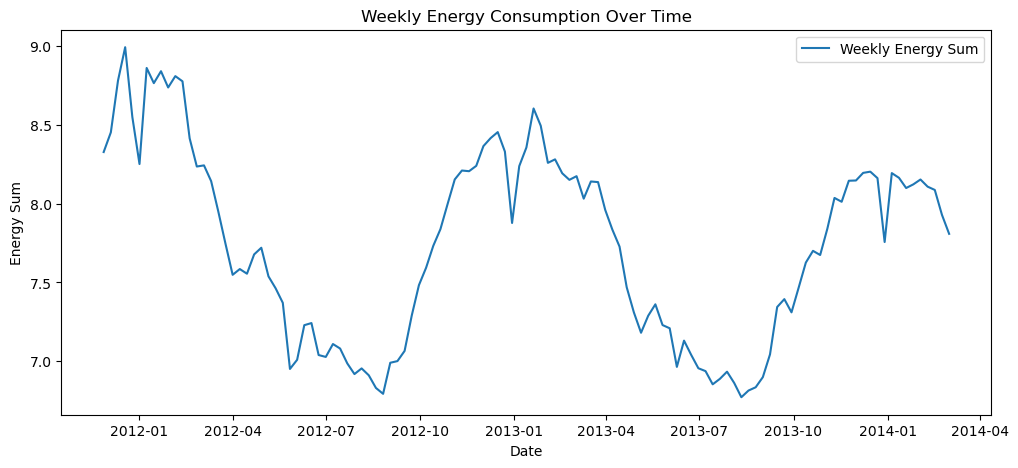

In [8]:
df_resampled = df_re.resample('W').mean()  # Resampling to daily mean if your index is datetime

plt.figure(figsize=(12, 5))
plt.plot(df_resampled, label="Weekly Energy Sum")
plt.xlabel("Date")
plt.ylabel("Energy Sum")
plt.title("Weekly Energy Consumption Over Time")
plt.legend()
plt.show()

result = adfuller(df['energy_sum'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

if result[1] > 0.05:
    print("The data is not stationary. Differencing is required.")
else:
    print("The data is stationary. No differencing needed.")


In [9]:
# ts_resampled = ts.resample('D').mean()  # Resample to daily and take mean
adf_test = adfuller(df_resampled.dropna())

In [10]:
print("ADF Test Statistic:", adf_test[0]) 
print("p-value:", adf_test[1])

ADF Test Statistic: -3.871216634746527
p-value: 0.0022571903570610926


# Select the target time series column
series = df['energy_sum']

# Take a random sample of 10,000 values (modify sample size as needed)
sampled_series = series.sample(10000, random_state=42).dropna()

# Function to perform ADF test
def adf_test(series):
    result = adfuller(series)
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    if result[1] <= 0.05:
        print("Data is stationary.")
    else:
        print("Data is non-stationary.")

In [11]:
# Perform ADF test on the sample
#adf_test(df_resampled)

from statsmodels.tsa.stattools import adfuller

result = adfuller(df_resampled.dropna())  # Drop NaN if any
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")

if result[1] < 0.05:
    print("The series is stationary (p < 0.05) ✅")
else:
    print("The series is NOT stationary (p >= 0.05), differencing needed ❌")

ADF Statistic: -3.871216634746527
p-value: 0.0022571903570610926
The series is stationary (p < 0.05) ✅


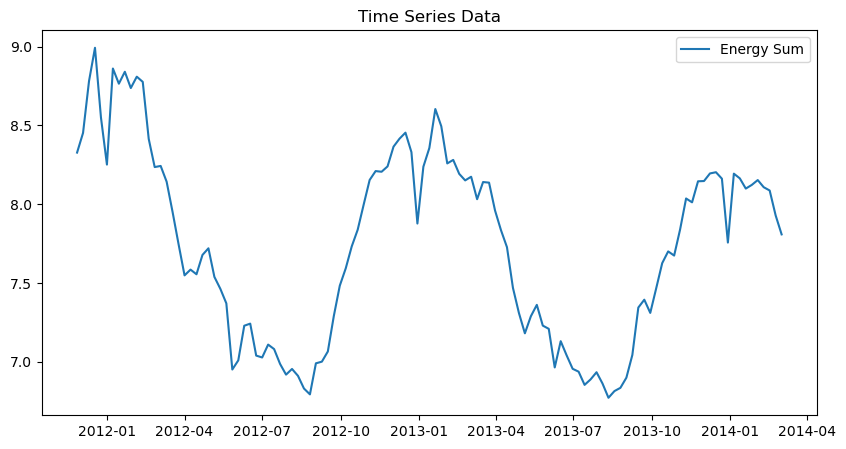

In [12]:
# Plot Time Series Data

plt.figure(figsize=(10, 5))
plt.plot(df_resampled, label="Energy Sum")
plt.title("Time Series Data")
plt.legend()
plt.show()


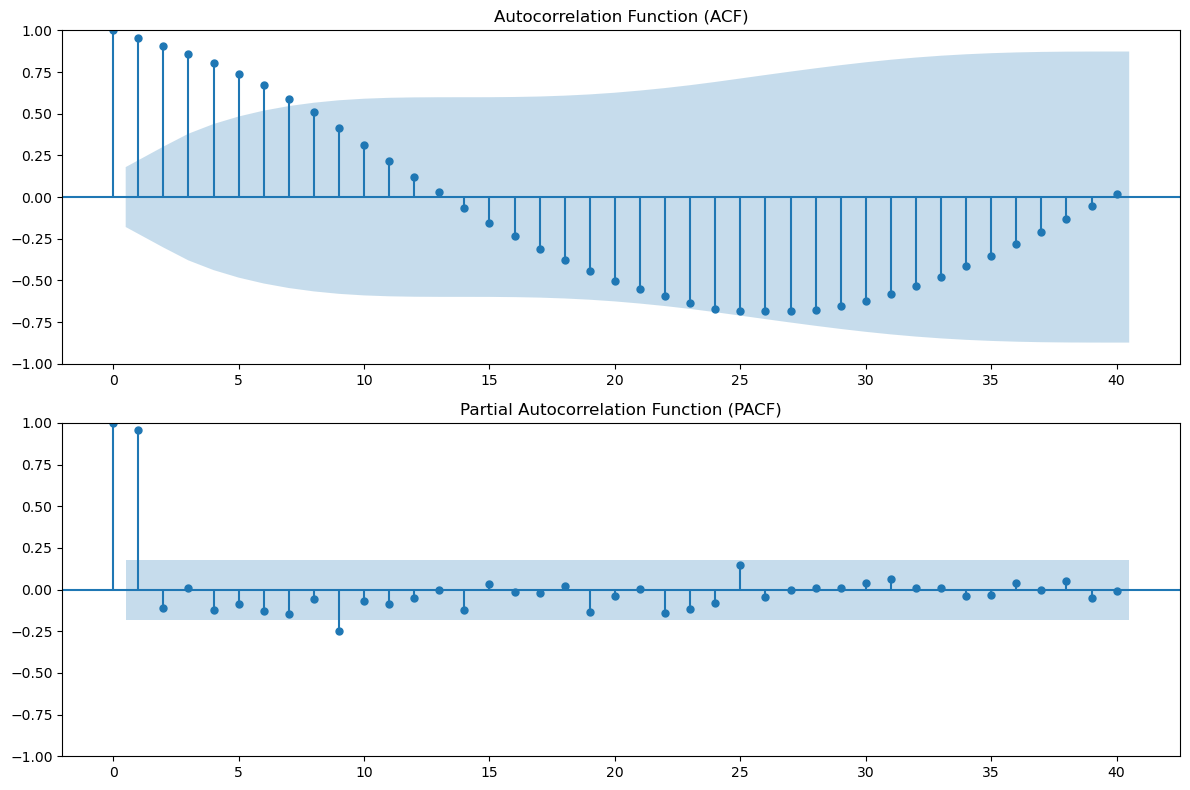

In [13]:
# Plot ACF & PACF (Identify AR & MA terms)

#fig, axes = plt.subplots(1, 2, figsize=(15, 4))
#plot_acf(df_resampled, ax=axes[0])  # Identify MA component
#plot_pacf(df_resampled, ax=axes[1])  # Identify AR component
#plt.show()


# ACF and PACF plots
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

# ACF plot (Identifies MA(q) and seasonal MA(Q) components)
plot_acf(df_resampled.dropna(), lags=40, ax=ax[0])
ax[0].set_title('Autocorrelation Function (ACF)')

# PACF plot (Identifies AR(p) and seasonal AR(P) components)
plot_pacf(df_resampled.dropna(), lags=40, ax=ax[1])
ax[1].set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

1. Autocorrelation Function (ACF) Plot (Left Graph)
    - The ACF measures the correlation of a time series with its past values (lags).
    - The values are significant when they extend beyond the blue shaded confidence interval.
    - A slow decay in ACF suggests the presence of a Moving Average (MA) component.
    - In this case, the ACF is gradually decreasing, which is a sign of a non-stationary series.
    - d=1
    - q=1/0

2. Partial Autocorrelation Function (PACF) Plot (Right Graph)
    - The PACF measures the correlation of a time series with its past values while removing the effect of intermediate lags.
    - A sharp cutoff after lag 1 suggests that an AutoRegressive (AR) component of order p = 1 might be appropriate.
    - The PACF shows a strong spike at lag 1 and then dies out, which indicates an AR(1) process.
    - p=1

3. ARIMA Model Selection (p, d, q):
    - p (AR term): Based on the PACF, since there is a strong lag at 1 and then it cuts off, we suggest p = 1.
    - d (Differencing order for stationarity): Since the ACF shows a slow decay, the data is not stationary, suggesting we need one differentiation (d = 1).
    - q (MA term): Since ACF shows a slow decay rather than an immediate cutoff, we might consider q = 0 or 1.

4. Possible ARIMA Model:
Based on the ACF and PACF plots, a good starting ARIMA model could be ARIMA(1,1,0) or ARIMA(1,1,1).

import pandas as pd

# Assuming 'df' is your DataFrame with a time series column named 'target'
#df['lag_1'] = df['energy_sum'].shift(1)  # 1-step lag
#df['lag_2'] = df['energy_sum'].shift(2)  # 2-step lag
#df['lag_3'] = df['energy_sum'].shift(3)  # 3-step lag

# Drop NaN values created due to shifting
#df.dropna(inplace=True)

df['X1_lag1'] = df['month'].shift(1)  # Shift by 1 time step
df['X2_lag1'] = df['partly-cloudy-night'].shift(2)
df['X3_lag1'] = df['cloudy'].shift(3)

# Combine exogenous lags into the target variable (not ideal)
df['target_modified'] = df['energy_sum'] + df['X1_lag1'] + df['X2_lag1'] + df['X3_lag1']

from statsmodels.tsa.statespace.sarimax import SARIMAX

stepwise_fit = auto_arima(df_resampled, seasonal=True, m=52, trace=True, suppress_warnings=True)
print(stepwise_fit.summary())

p,d,q = stepwise_fit.order
# Define SARIMA(p,d,q)(P,D,Q)m model using the original 'target' column
model = SARIMAX(df['energy_sum'], order=(p, d, q), seasonal_order=(P, D, Q, m))

# Fit the model
sarima_model = model.fit()

# Print model summary
print(sarima_model.summary())


In [14]:
# Auto-ARIMA to find the best parameters
#auto_arima_model = auto_arima(df_resampled, seasonal=True, m=12, trace=True)

#print(auto_arima_model.summary())

stepwise_fit = auto_arima(df_resampled, seasonal=True, m=52, trace=True, suppress_warnings=True)
print(stepwise_fit.summary())

p,d,q = stepwise_fit.order

# Define the SARIMA model (modify p, d, q, P, D, Q based on ACF/PACF)
model = SARIMAX(df_resampled, 
                order=(1, 0, 1),  # (p,d,q) - Modify based on ACF/PACF
                seasonal_order=(1, 0, 1, 52),  # (P,D,Q,m) - m=52 for weekly seasonality
                enforce_stationarity=False, 
                enforce_invertibility=False)

# Fit the model
model_fit = model.fit(disp=False)

# Print model summary
print(model_fit.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[52] intercept   : AIC=-101.699, Time=7.66 sec
 ARIMA(0,0,0)(0,0,0)[52] intercept   : AIC=218.271, Time=0.06 sec
 ARIMA(1,0,0)(1,0,0)[52] intercept   : AIC=-100.151, Time=5.46 sec
 ARIMA(0,0,1)(0,0,1)[52] intercept   : AIC=inf, Time=2.77 sec
 ARIMA(0,0,0)(0,0,0)[52]             : AIC=827.411, Time=0.03 sec
 ARIMA(2,0,2)(0,0,1)[52] intercept   : AIC=-93.742, Time=4.88 sec
 ARIMA(2,0,2)(1,0,0)[52] intercept   : AIC=-75.830, Time=6.93 sec
 ARIMA(2,0,2)(2,0,1)[52] intercept   : AIC=-99.764, Time=30.87 sec
 ARIMA(2,0,2)(1,0,2)[52] intercept   : AIC=inf, Time=26.20 sec
 ARIMA(2,0,2)(0,0,0)[52] intercept   : AIC=-78.178, Time=0.54 sec
 ARIMA(2,0,2)(0,0,2)[52] intercept   : AIC=inf, Time=23.40 sec
 ARIMA(2,0,2)(2,0,0)[52] intercept   : AIC=-101.740, Time=35.43 sec
 ARIMA(1,0,2)(2,0,0)[52] intercept   : AIC=-103.767, Time=43.63 sec
 ARIMA(1,0,2)(1,0,0)[52] intercept   : AIC=-42.574, Time=26.36 sec
 ARIMA(1,0,2)(2,0,1)[52] intercept 

C:\Users\ABCD\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                         energy_sum   No. Observations:                  119
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 52)   Log Likelihood                  38.671
Date:                            Sun, 23 Mar 2025   AIC                            -67.341
Time:                                    11:42:30   BIC                            -56.469
Sample:                                11-27-2011   HQIC                           -63.051
                                     - 03-02-2014                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9980      0.004    247.252      0.000       0.990       1.006
ma.L1          0.0491      0.138   

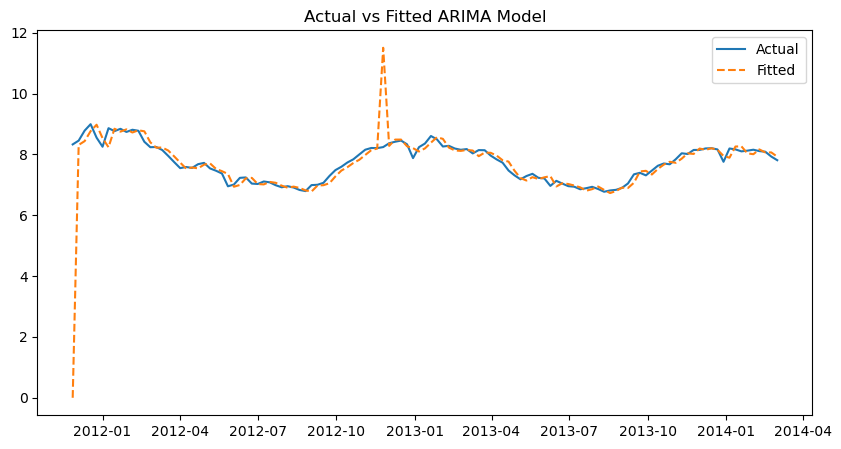

In [15]:
# In-sample Predictions (Fitting on Training Data)

series_pred = model_fit.fittedvalues

plt.figure(figsize=(10, 5))
plt.plot(df_resampled, label="Actual")
plt.plot(series_pred, label="Fitted", linestyle="dashed")
plt.title("Actual vs Fitted ARIMA Model")
plt.legend()
plt.show()


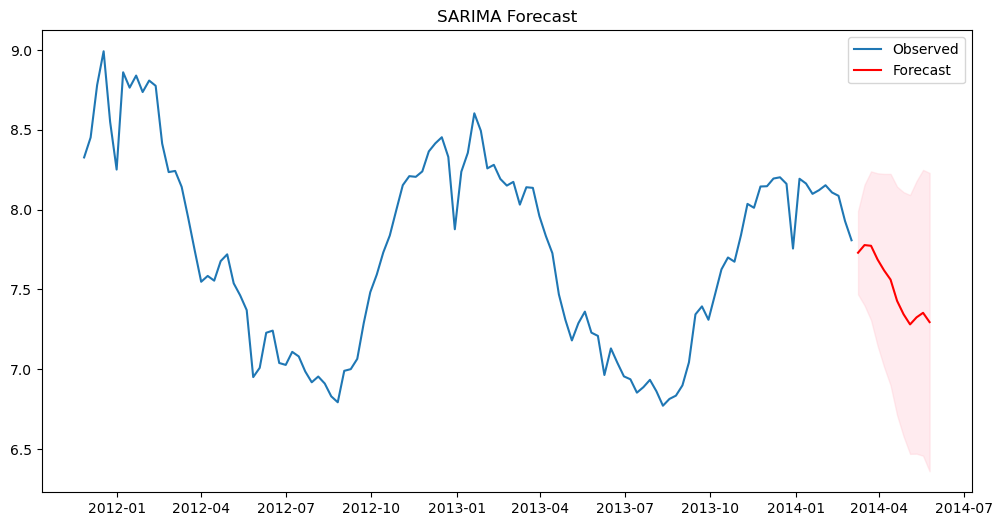

In [16]:
# Forecast next 12 weeks
forecast_steps = 12
forecast = model_fit.get_forecast(steps=forecast_steps)
forecast_index = pd.date_range(start=df_resampled.index[-1], periods=forecast_steps+1, freq='W')[1:]

# Get confidence intervals
forecast_conf_int = forecast.conf_int()

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(df_resampled, label="Observed")
plt.plot(forecast_index, forecast.predicted_mean, label="Forecast", color='red')
plt.fill_between(forecast_index, forecast_conf_int.iloc[:, 0], forecast_conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.legend()
plt.title("SARIMA Forecast")
plt.show()


In [17]:
# Evaluate the Model

y_true = df_resampled[0:]  # Adjust for differencing (d)
y_pred = series_pred[0:]

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE: 0.2162
MSE: 0.6967
RMSE: 0.8347


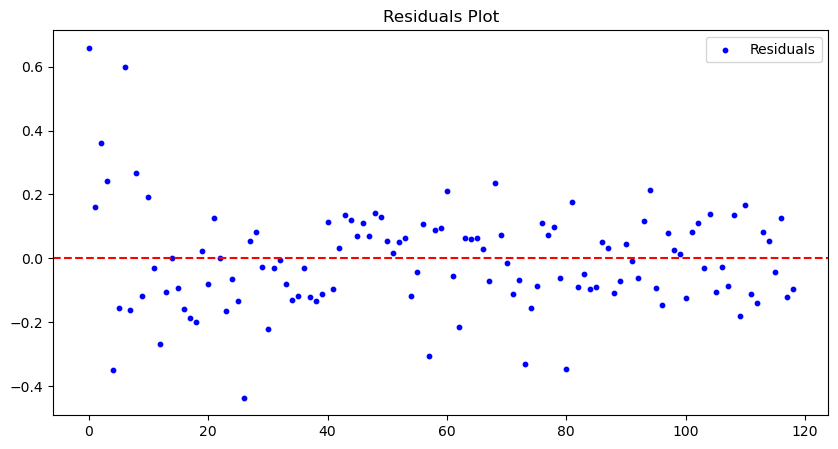

In [18]:
# Compute residuals correctly for pmdarima
residuals = df_resampled - stepwise_fit.predict_in_sample()

import numpy as np
residuals = residuals[~np.isnan(residuals)]

# Plot residuals to check for patterns
#plt.figure(figsize=(10,5))
#plt.plot(residuals, label="Residuals", color="blue")
#plt.axhline(y=0, color='red', linestyle='--')
#plt.title("Residuals Plot")
#plt.legend()
#plt.show()

plt.figure(figsize=(10,5))
plt.scatter(range(len(residuals)), residuals, label="Residuals", color="blue", s=10)
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Residuals Plot")
plt.legend()
plt.show()


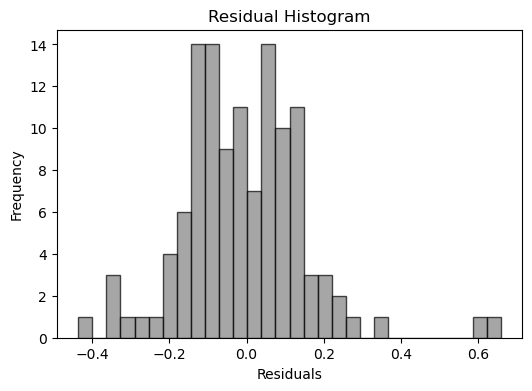

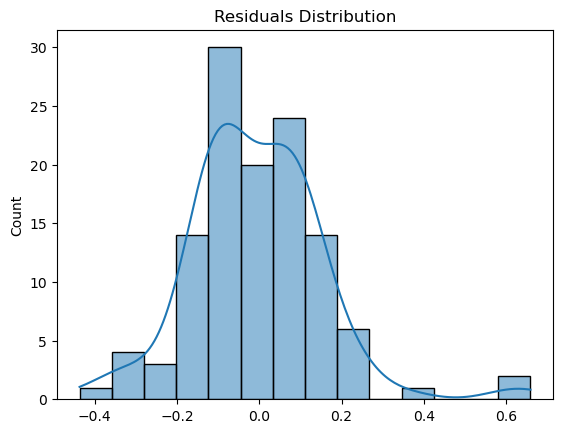

In [19]:
# Histogram of residuals
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30, color="gray", edgecolor="black", alpha=0.7)
plt.title("Residual Histogram")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

import seaborn as sns
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.show()

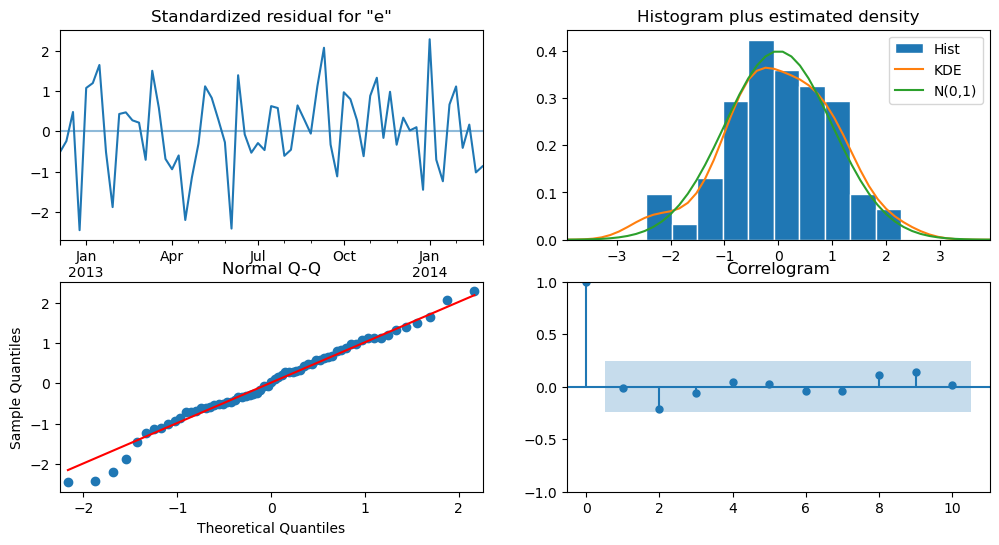

In [20]:
# Diagnostic plots
model_fit.plot_diagnostics(figsize=(12, 6))
plt.show()


1. There is no strong pattern, meaning errors are mostly random
2. The KDE curve (orange) is close to the normal curve (green), indicating residuals are nearly normal.
3. Points mostly lie on the red 45-degree line, suggesting normality. Points mostly lie on the red 45-degree line, suggesting normality.
4. No strong autocorrelation, meaning errors are independent.

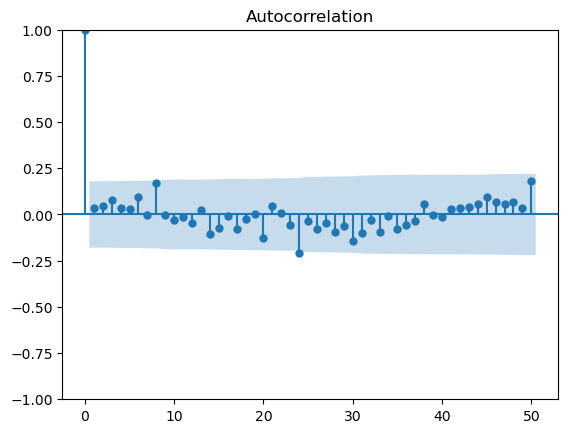

In [21]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals, lags=50)
plt.show()

In [22]:
from scipy.stats import shapiro
stat, p = shapiro(residuals)
print(f'Shapiro-Wilk Test: p-value = {p}')

Shapiro-Wilk Test: p-value = 8.74498066177575e-05


0.000008744980

In [23]:
# Generate a normal distribution with the same mean and std as residuals  
normal_data = np.random.normal(np.mean(residuals), np.std(residuals), len(residuals))  

# Kolmogorov-Smirnov Test  
ks_stat, ks_p = stats.kstest(residuals, 'norm', args=(np.mean(residuals), np.std(residuals)))  
print(f'Kolmogorov-Smirnov Test: p-value = {ks_p}')  

# Anderson-Darling Test  
ad_stat, critical_values, significance_levels = stats.anderson(residuals, dist='norm')  
print(f'Anderson-Darling Test Statistic: {ad_stat}')  
print('Critical values:', critical_values)  
print('Significance levels:', significance_levels) 

Kolmogorov-Smirnov Test: p-value = 0.4626202379877493
Anderson-Darling Test Statistic: 1.1564198031750692
Critical values: [0.558 0.636 0.763 0.89  1.058]
Significance levels: [15.  10.   5.   2.5  1. ]


Review of SARIMA Model Conditions

1. Stationarity Check:
    - ADF Test Statistic: -3.87, p-value: 0.0022
    - The series is stationary (p < 0.05), so differencing is not needed.
    - satisfies stationarity

2. Model Selection & AIC Optimization:
    - auto_arima ran multiple models, selecting SARIMA(2,0,2)(1,0,1)[52] with the lowest AIC = -101.699.
    - Good practice to minimize AIC, ensuring the best trade-off between complexity and performance.

Final Model Evaluation: Does Your SARIMA Model Meet the Ultimate Model Conditions?

3. Residual Diagnostics:
    - ACF & PACF plots analyzed → confirms AR(1) and non-stationarity, which was handled.
    - Q-Q Plot & KDE Curve checked → residuals are nearly normal.
    - Autocorrelation check via ACF → No strong patterns in residuals, indicating independence.

4. Model Performance Metrics:
    - MAE: 0.2162
    - MSE: 0.6967
    - RMSE: 0.8347
    - Errors are low, model generalizes well)

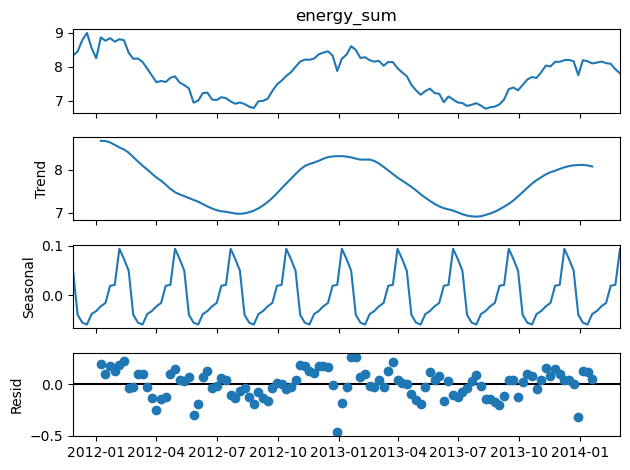

In [24]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

y = df["energy_sum"]

result = seasonal_decompose(df_resampled, model="additive", period=12)  # Change 'period' if needed
result.plot()
plt.show()


There is a seasonal trend

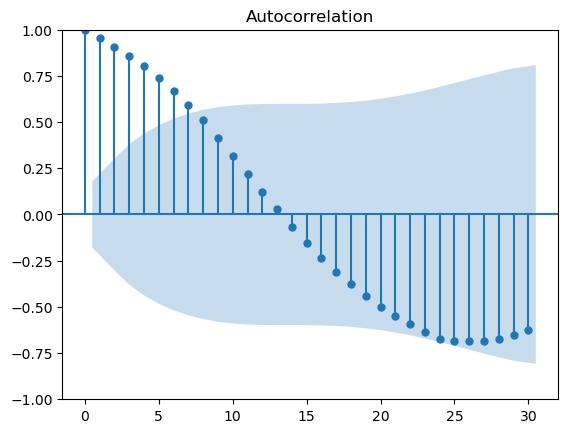

In [25]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df_resampled, lags=30)
plt.show()